In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve , auc , accuracy_score , f1_score
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv('after_knn.csv')

FileNotFoundError: ignored

In [ ]:
df.drop(['Unnamed: 0','SK_ID_CURR'] , axis = 1 , inplace = True)

In [ ]:
df.head()

,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,...,DEF_60_CNT_SOCIAL_CIRCLE_1.0,DEF_60_CNT_SOCIAL_CIRCLE_2.0,DEF_60_CNT_SOCIAL_CIRCLE_3.0,DEF_60_CNT_SOCIAL_CIRCLE_4.0,DEF_60_CNT_SOCIAL_CIRCLE_5.0,DEF_60_CNT_SOCIAL_CIRCLE_6.0,DEF_60_CNT_SOCIAL_CIRCLE_7.0,DEF_60_CNT_SOCIAL_CIRCLE_24.0,CNT_FAM_MEMBERS__small family,TARGET
0,0.137117,-9461.0,-637.0,60.398675,-2120.0,-1.0,0.0,0.0,0.0,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
1,0.059506,-16765.0,-1188.0,34.438351,-291.0,-1.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
2,0.100160,-19046.0,-225.0,65.268675,-2531.0,26.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3,0.089549,-19005.0,-3039.0,99.161484,-2437.0,-1.0,0.0,0.0,0.0,0.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,0.169302,-19932.0,-3038.0,65.658206,-3458.0,-1.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0


In [ ]:
df['TARGET'].value_counts(normalize = True)*100

0    91.94793
1     8.05207
Name: TARGET, dtype: float64

C:\Users\saketh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='TARGET', ylabel='count'>

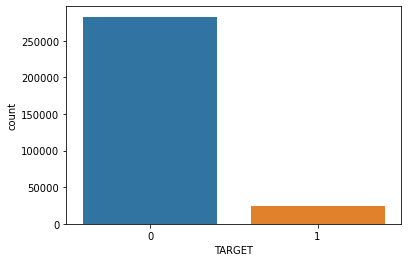

In [ ]:
sns.countplot(df['TARGET'])

In [ ]:
#df.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 162 columns):
 #   Column                                             Dtype  
---  ------                                             -----  
 0   Unnamed: 0                                         int64  
 1   SK_ID_CURR                                         float64
 2   AMT_INCOME_TOTAL                                   float64
 3   AMT_CREDIT                                         float64
 4   AMT_ANNUITY                                        float64
 5   AMT_GOODS_PRICE                                    float64
 6   REGION_POPULATION_RELATIVE                         float64
 7   DAYS_BIRTH                                         float64
 8   DAYS_EMPLOYED                                      float64
 9   DAYS_REGISTRATION                                  float64
 10  DAYS_ID_PUBLISH                                    float64
 11  OWN_CAR_AGE                                        

In [ ]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm


# WIthout scaling

In [ ]:
X = df.drop('TARGET' , axis = 1)
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X , y, test_size=0.3, random_state=42)


model = sm.Logit(y,Xc).fit()
model.summary()

         Current function value: 0.279040
         Iterations: 35


C:\Users\saketh\anaconda3\lib\site-packages\statsmodels\base\model.py:566: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 TARGET   No. Observations:               307511
Model:                          Logit   Df Residuals:                   307393
Method:                           MLE   Df Model:                          117
Date:                Thu, 01 Jul 2021   Pseudo R-squ.:                0.003568
Time:                        11:38:52   Log-Likelihood:                -85808.
converged:                      False   LL-Null:                       -86115.
Covariance Type:            nonrobust   LLR p-value:                 1.508e-68
=====================================================================================================================
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
const                                               -47.2292        nan        nan        nan         nan         nan
Unnamed: 0                                         7.401e-07   4.57e-07      1.620      0.105   -1.55e-07    1.64e-06
SK_ID_CURR                                        -6.354e-09   6.78e-08     -0.094      0.925   -1.39e-07    1.27e-07
REGION_POPULATION_RELATIVE                            0.3176      0.184      1.727      0.084      -0.043       0.678
DAYS_BIRTH                                         2.832e-06   2.41e-06      1.176      0.240   -1.89e-06    7.55e-06
DAYS_EMPLOYED                                      1.857e-05   5.08e-06      3.659      0.000    8.62e-06    2.85e-05
DAYS_REGISTRATION                                    -0.0002      0.000     -0.608      0.543      -0.001       0.000
DAYS_ID_PUBLISH                                   -1.779e-06   4.71e-06     -0.377      0.706    -1.1e-05    7.46e-06
OWN_CAR_AGE                                           0.0010      0.001      1.068      0.286      -0.001       0.003
AMT_REQ_CREDIT_BUREAU_HOUR                            0.0042      0.084      0.050      0.960      -0.160       0.168
AMT_REQ_CREDIT_BUREAU_DAY                             0.0952      0.059      1.601      0.109      -0.021       0.212
AMT_REQ_CREDIT_BUREAU_WEEK                           -0.0013      0.035     -0.039      0.969      -0.069       0.066
AMT_REQ_CREDIT_BUREAU_MON                            -0.0020      0.008     -0.254      0.799      -0.017       0.013
AMT_REQ_CREDIT_BUREAU_QRT                            -0.0101      0.011     -0.904      0.366      -0.032       0.012
AMT_REQ_CREDIT_BUREAU_YEAR                            0.0057      0.004      1.500      0.134      -0.002       0.013
LOG_AMT_INCOME_TOTAL                                 -0.0153      0.018     -0.857      0.392      -0.050       0.020
FLAG_DOC_SCORE                                        1.0524      3.679      0.286      0.775      -6.158       8.263
EXT_SOURCE_AVG                                       -0.6716      0.048    -13.856      0.000      -0.767      -0.577
LOG_AMT_CREDIT                                        0.3156      0.067      4.691      0.000       0.184       0.447
LOG_AMT_ANNUITY                                       0.0524      0.025      2.071      0.038       0.003       0.102
LOG_AMT_GOODS_PRICE                                  -0.3046      0.068     -4.472      0.000      -0.438      -0.171
DAYS_LAST_PHONE_CHANGE_TR                            -0.0075      0.007     -1.079      0.280      -0.021       0.006
NAME_CONTRACT_TYPE_Revolving loans                   -0.0183      0.028     -0.665      0.506      -0.072       0.036
CODE_GENDER_M                                         0.0566      0.017      3.388      0.001       0.024       0.089
FLAG_OWN_CAR_Y                                       -0

In [2]:
X = df.drop('TARGET' , axis = 1)
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


lgr = LogisticRegression(max_iter = 1000)
base_model = lgr.fit(X_train,y_train)

NameError: ignored

In [1]:
y_train.value_counts()

NameError: ignored

In [ ]:
base_model.score(X_train , y_train)

0.919547331794088

In [ ]:
f1_score(y_test , base_model.predict(X_test))

0.0

In [ ]:
from sklearn.metrics import confusion_matrix , classification_report

In [ ]:
y_test_pred = base_model.predict(X_test)
confusion_matrix(y_test , y_test_pred)

array([[84811,     0],
       [ 7443,     0]], dtype=int64)

In [ ]:
pd.DataFrame(confusion_matrix(y_test , y_test_pred) , index = ['0 Actual','1 Actual'] , columns =['0 predicted','1 Predicted'])
#logistic regression

,0 predicted,1 Predicted
0 Actual,84811,0
1 Actual,7443,0


In [ ]:
print(classification_report(y_test , y_test_pred))

C:\Users\saketh\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\saketh\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.92      1.00      0.96     84811
           1       0.00      0.00      0.00      7443

    accuracy                           0.92     92254
   macro avg       0.46      0.50      0.48     92254
weighted avg       0.85      0.92      0.88     92254



C:\Users\saketh\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
y_test_proba = base_model.predict_proba(X_test)
fpr , tpr , t = roc_curve(y_test , y_test_proba[:,1])
auc(fpr , tpr)

0.5092456688590418

In [ ]:
from sklearn.feature_selection import RFE

In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector as sfs

In [ ]:
# sf= sfs(lgr , k_features = 'best' , cv = 3 , scoring ='f1_weighted')
# sf.fit(X_train , y_train)

In [ ]:
# rfe = RFE(lgr , n_features_to_select = 20)
# rfe.fit(X_train , y_train)

## Decision Tree

In [ ]:
clf = DecisionTreeClassifier(random_state = 0)
dt_1 = clf.fit(X_train , y_train)
print('f1_score:', f1_score(y_test ,dt_1.predict(X_test) ))

f1_score: 0.09194700531167958


In [ ]:
y_test_pred = dt_1.predict(X_test)

In [ ]:
pd.DataFrame(confusion_matrix(y_test , y_test_pred) , index = ['0 Actual','1 Actual'] , columns =['0 predicted','1 Predicted'])

,0 predicted,1 Predicted
0 Actual,76628,8183
1 Actual,6690,753


In [ ]:
print(classification_report(y_test , dt_1.predict(X_test)))

              precision    recall  f1-score   support

           0       0.92      0.93      0.92     84811
           1       0.09      0.08      0.08      7443

    accuracy                           0.86     92254
   macro avg       0.50      0.50      0.50     92254
weighted avg       0.85      0.86      0.86     92254



In [ ]:
 # Grid Search

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
# 3 , 21 , 41 , 61

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
X = df.drop('TARGET' , axis = 1)
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
depth = np.arange(61,81,1)
criterion =['gini','entropy']

In [ ]:
clf = DecisionTreeClassifier(random_state = 0)
params =[{'max_depth' : depth,
         'criterion': criterion}]
gs = GridSearchCV(clf , param_grid = params , scoring = 'f1_weighted', cv = 3)
gs.fit(X_train , y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=0),
             param_grid=[{'criterion': ['gini', 'entropy'],
                          'max_depth': array([61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77,
       78, 79, 80])}],
             scoring='f1_weighted')

In [ ]:
gs.best_params_

{'criterion': 'entropy', 'max_depth': 61}

In [ ]:
clf = DecisionTreeClassifier(max_depth = 41 , random_state = 0)
dt_1 = clf.fit(X_train , y_train)
print('f1_score:', f1_score(y_test ,dt_1.predict(X_test) ))

f1_score: 0.08434325744308231


In [ ]:
clf = DecisionTreeClassifier(max_depth = 61 , random_state = 0)
dt_1 = clf.fit(X_train , y_train)
print('f1_score:', f1_score(y_test ,dt_1.predict(X_test) ))

f1_score: 0.08948628245258701


In [ ]:
# Default features

# Random FOrest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(n_estimators = 10 , random_state =0)
model_rf = rf.fit(X_train , y_train)

In [ ]:
f1_score(y_test , model_rf.predict(X_test))

0.0005361930294906167

In [ ]:
confusion_matrix(y_test , model_rf.predict(X_test))

array([[84796,    15],
       [ 7441,     2]], dtype=int64)

In [ ]:
print(classification_report(y_test , model_rf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     84811
           1       0.12      0.00      0.00      7443

    accuracy                           0.92     92254
   macro avg       0.52      0.50      0.48     92254
weighted avg       0.85      0.92      0.88     92254

